In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [2]:
xlsx=pd.ExcelFile('glass.xlsx')
xlsx.sheet_names

['Description', 'glass']

In [4]:
df=pd.read_excel('glass.xlsx',sheet_name='glass')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
df.shape

(214, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [9]:
df.duplicated().sum()

np.int64(0)

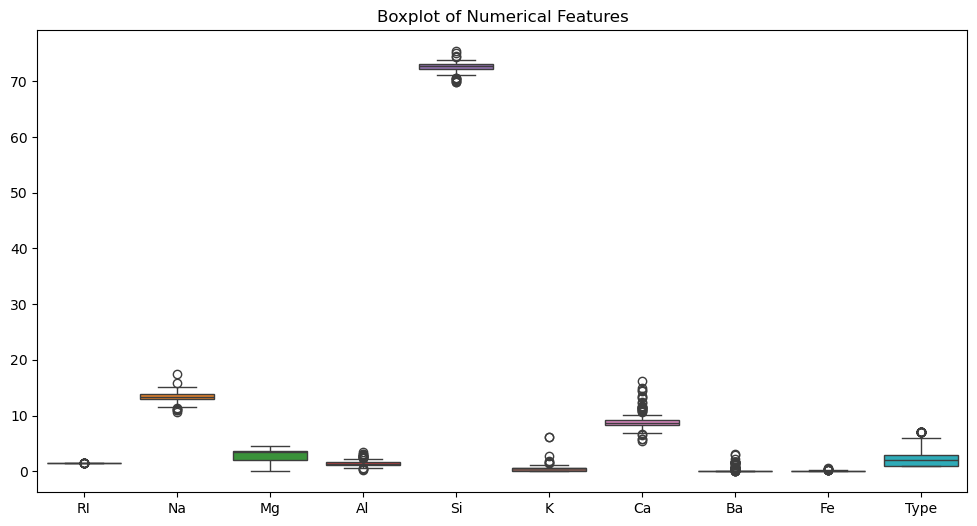

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot of Numerical Features")
plt.show()


In [11]:
# Select only numeric columns (non-numeric columns are ignored for outlier removal)
numeric_df = df.select_dtypes(include=[np.number])

# Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR for each numeric column
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Define outlier condition mask
outlier_mask = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))

# Filter the DataFrame: keep only rows where no numeric value is an outlier
df_clean = df[~outlier_mask.any(axis=1)]

# Compare shapes
print("Shape before removing outliers:", df.shape)
print("Shape after removing outliers:", df_clean.shape)


Shape before removing outliers: (213, 10)
Shape after removing outliers: (135, 10)


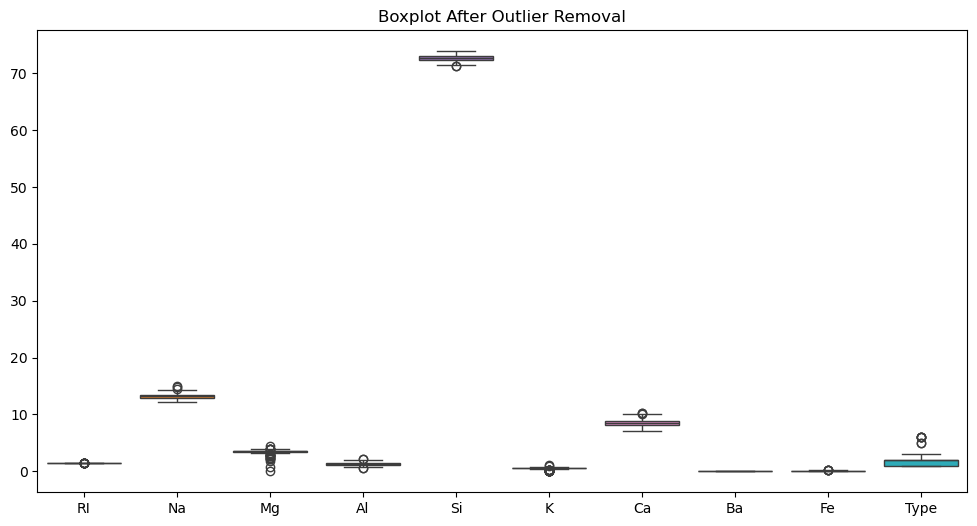

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean)
plt.title("Boxplot After Outlier Removal")
plt.show()


In [13]:
X = df_clean.drop('Type', axis=1)
y = df_clean['Type']


In [17]:
class_counts = df['Type'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print("Imbalance Ratio:", imbalance_ratio)


Imbalance Ratio: 8.444444444444445


In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [23]:
from imblearn.over_sampling import SMOTE

In [26]:
sm = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = sm.fit_resample(X_scaled, y)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)


Random Forest Results:
Accuracy: 0.9325842696629213
Precision: 0.9306501547987617
Recall: 0.9313725490196078
F1 Score: 0.9307290483761073

Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.83      0.86        18
           2       0.82      0.82      0.82        17
           3       1.00      1.00      1.00        18
           5       1.00      1.00      1.00        18
           6       0.95      1.00      0.97        18

    accuracy                           0.93        89
   macro avg       0.93      0.93      0.93        89
weighted avg       0.93      0.93      0.93        89



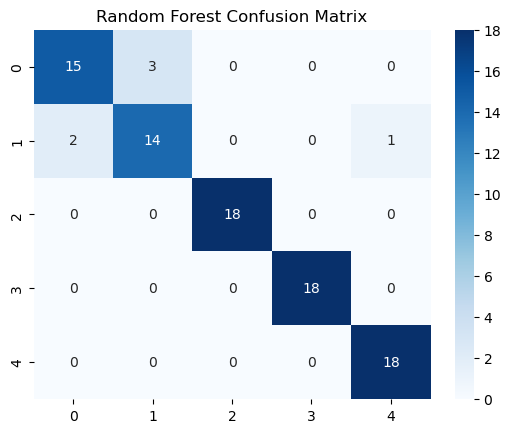

In [28]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()


=== Bagging Classifier Performance ===
Accuracy: 0.8876404494382022
Precision: 0.8834022556390977
Recall: 0.8862745098039216
F1-Score: 0.8822402822402822

Classification Report:
               precision    recall  f1-score   support

           1       0.80      0.67      0.73        18
           2       0.81      0.76      0.79        17
           3       0.86      1.00      0.92        18
           5       1.00      1.00      1.00        18
           6       0.95      1.00      0.97        18

    accuracy                           0.89        89
   macro avg       0.88      0.89      0.88        89
weighted avg       0.88      0.89      0.88        89



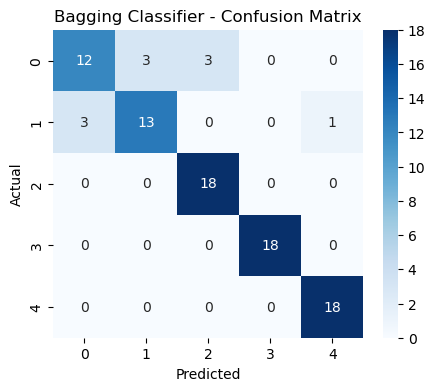

In [34]:

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  
    n_estimators=100,
    random_state=42
)

# Train the Bagging model
bagging.fit(X_train, y_train)

# Make predictions
y_bag = bagging.predict(X_test)

# --- Evaluation ---
print("=== Bagging Classifier Performance ===")
print("Accuracy:", accuracy_score(y_test, y_bag))
print("Precision:", precision_score(y_test, y_bag, average='macro'))
print("Recall:", recall_score(y_test, y_bag, average='macro'))
print("F1-Score:", f1_score(y_test, y_bag, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_bag))

# --- Confusion Matrix ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_bag), annot=True, fmt='d', cmap='Blues')
plt.title("Bagging Classifier - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== AdaBoost Classifier ===
Accuracy: 0.8764044943820225
Precision: 0.8779557903396913
Recall: 0.8758169934640524
F1-Score: 0.8712359608185036

Classification Report:
               precision    recall  f1-score   support

           1       0.85      0.61      0.71        18
           2       0.82      0.82      0.82        17
           3       0.77      0.94      0.85        18
           5       1.00      1.00      1.00        18
           6       0.95      1.00      0.97        18

    accuracy                           0.88        89
   macro avg       0.88      0.88      0.87        89
weighted avg       0.88      0.88      0.87        89



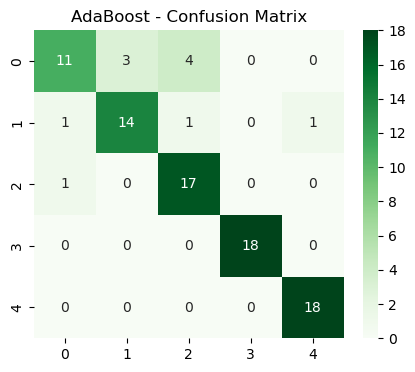

In [35]:
adaboost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

adaboost.fit(X_train, y_train)
y_ada = adaboost.predict(X_test)

print("=== AdaBoost Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_ada))
print("Precision:", precision_score(y_test, y_ada, average='macro'))
print("Recall:", recall_score(y_test, y_ada, average='macro'))
print("F1-Score:", f1_score(y_test, y_ada, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_ada))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_ada), annot=True, fmt='d', cmap='Greens')
plt.title("AdaBoost - Confusion Matrix")
plt.show()


=== Gradient Boosting Classifier ===
Accuracy: 0.9213483146067416
Precision: 0.9266666666666665
Recall: 0.9209150326797385
F1-Score: 0.9216678058783323

Classification Report:
               precision    recall  f1-score   support

           1       0.80      0.89      0.84        18
           2       0.83      0.88      0.86        17
           3       1.00      0.83      0.91        18
           5       1.00      1.00      1.00        18
           6       1.00      1.00      1.00        18

    accuracy                           0.92        89
   macro avg       0.93      0.92      0.92        89
weighted avg       0.93      0.92      0.92        89



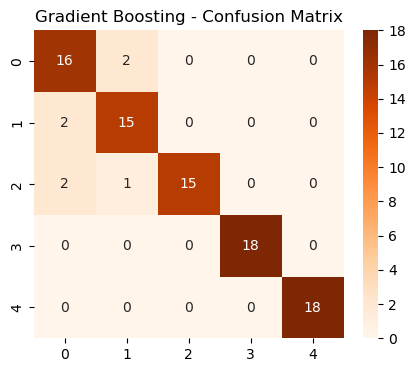

In [36]:
gradboost = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gradboost.fit(X_train, y_train)
y_gb = gradboost.predict(X_test)

print("=== Gradient Boosting Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_gb))
print("Precision:", precision_score(y_test, y_gb, average='macro'))
print("Recall:", recall_score(y_test, y_gb, average='macro'))
print("F1-Score:", f1_score(y_test, y_gb, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_gb))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_gb), annot=True, fmt='d', cmap='Oranges')
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()


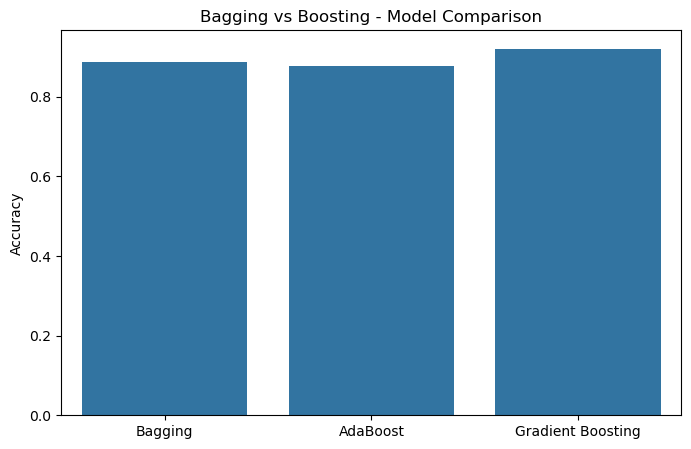

In [37]:
models = ['Bagging', 'AdaBoost', 'Gradient Boosting']
accuracies = [
    accuracy_score(y_test, y_bag),
    accuracy_score(y_test, y_ada),
    accuracy_score(y_test, y_gb)
]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)
plt.ylabel("Accuracy")
plt.title("Bagging vs Boosting - Model Comparison")
plt.show()


#### Bagging vs Boosting:

###### Bagging (Bootstrap Aggregating) trains multiple models independently on random subsets of the data (with replacement) and combines their predictions through voting or averaging. It mainly aims to reduce variance and prevent overfitting, with Random Forest being a common example. Boosting, on the other hand, builds models sequentially, where each new model focuses on correcting the errors of the previous one. It combines weak learners to form a strong model, reducing bias and improving accuracy. Examples include AdaBoost, Gradient Boosting, and XGBoost. The key difference is that Bagging trains models in parallel to reduce variance, while Boosting trains them sequentially to reduce bias.

#### Handling Imbalanced Data:

###### Imbalanced data can be managed through several techniques. Resampling methods include oversampling (e.g., SMOTE) to duplicate or synthesize minority class samples and undersampling to reduce the size of the majority class. Algorithmic methods involve using models with class weights, such as setting class_weight='balanced' in Random Forest, to give more importance to minority classes. Finally, evaluation methods should use metrics like F1-score, Precision, Recall, and ROC-AUC instead of only accuracy to better assess performance on imbalanced datasets.